# W2 D24 — Clustering: User Segmentation
**Topics:** Synthetic MedPulse users | KMeans, DBSCAN, Elbow/Silhouette, segment profiling

**Q1** EDA — feature distributions
**Q2** KMeans — elbow + silhouette
**Q3** Cluster visualization (PCA 2D)
**Q4** DBSCAN — noise detection
**Q5** Segment profiling & business names


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings; warnings.filterwarnings('ignore')
np.random.seed(420)
print('Libraries loaded')
sns.set_theme(style='whitegrid')

Libraries loaded


In [2]:
# Synthetic MedPulse user segments
n = 2000
np.random.seed(420)
# 4 natural clusters
segments = [
    {'name':'High-Engagement',  'n':500,  'visits':np.random.normal(15, 2, 500), 'articles':np.random.normal(20, 3, 500), 'age':np.random.normal(38, 5, 500), 'appt_rate':np.random.normal(0.7, 0.1, 500)},
    {'name':'Casual-Browser',   'n':700,  'visits':np.random.normal(4,  1, 700), 'articles':np.random.normal(3,  1, 700), 'age':np.random.normal(28, 6, 700), 'appt_rate':np.random.normal(0.1, 0.05,700)},
    {'name':'Appointment-Only', 'n':400,  'visits':np.random.normal(6,  2, 400), 'articles':np.random.normal(5,  2, 400), 'age':np.random.normal(52, 7, 400), 'appt_rate':np.random.normal(0.8, 0.1, 400)},
    {'name':'Health-Researcher','n':400,  'visits':np.random.normal(10, 3, 400), 'articles':np.random.normal(30, 5, 400), 'age':np.random.normal(45, 8, 400), 'appt_rate':np.random.normal(0.3, 0.1, 400)},
]
rows = []
for seg in segments:
    n_seg = seg['n']
    for i in range(n_seg):
        rows.append({'visits_per_month':max(1, seg['visits'][i]),
                     'articles_read':max(0, seg['articles'][i]),
                     'age':max(18, min(80, seg['age'][i])),
                     'appt_rate':np.clip(seg['appt_rate'][i], 0, 1),
                     'true_segment':seg['name']})
df = pd.DataFrame(rows)
print(f'Dataset: {df.shape}')
display(df.head())

Dataset: (2000, 5)


,visits_per_month,articles_read,age,appt_rate,true_segment
0,14.029218,20.319569,39.242358,0.697962,High-Engagement
1,11.189692,21.377833,40.620590,0.806494,High-Engagement
2,13.947556,13.337109,40.124388,0.855794,High-Engagement
3,14.372908,23.417095,42.816001,0.685822,High-Engagement
4,15.661413,25.629510,41.800951,0.511115,High-Engagement


## Q1 — EDA: Feature Distributions

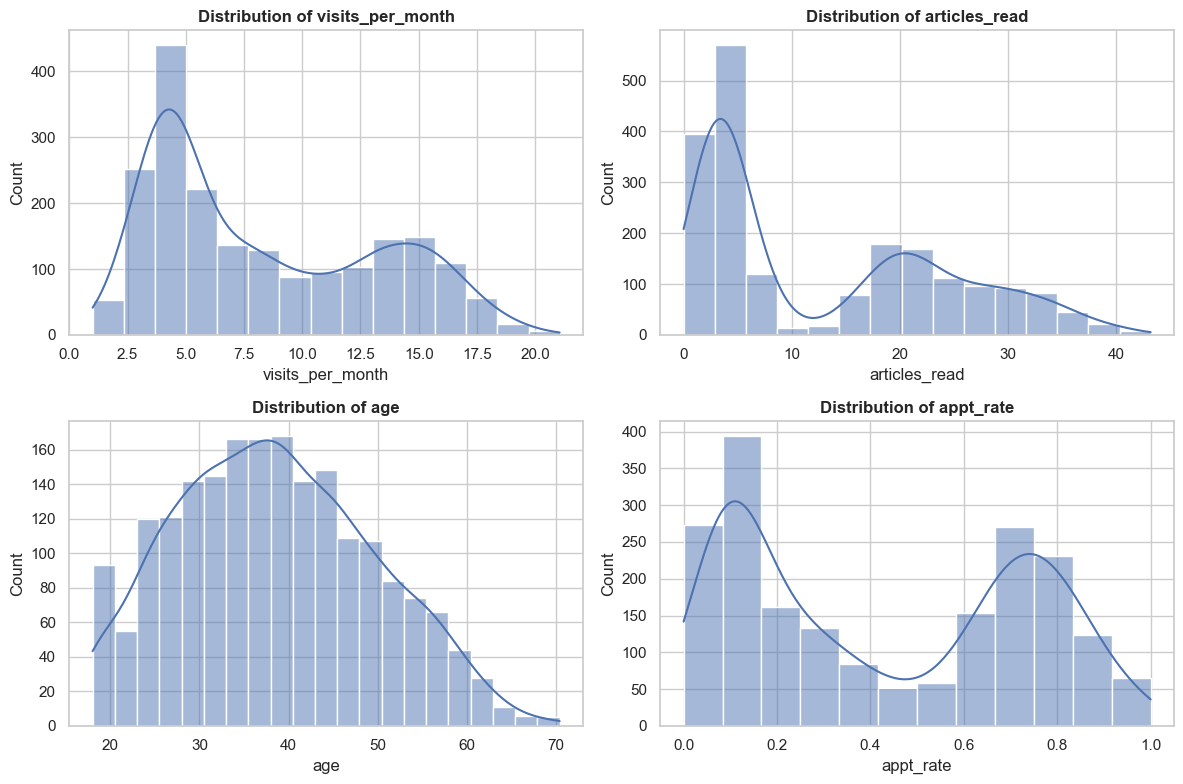

In [12]:
# 1. Dynamically capture only true numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_features = len(numeric_cols)

# 2. Dynamically calculate required grid dimensions (fixing it at 2 columns wide)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

# 3. Initialize the adaptive canvas layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()  # Flatten array to iterate smoothly in a single 1D loop

# 4. Loop through features and generate plots
for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df, 
        x=col, 
        kde=True,           
        multiple="stack",   
        ax=axes[i],
        palette='tab10'
    )
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# 5. Clean Up: Turn off and hide empty canvas slots if feature count is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

*** Takeaways from the plot:

1/ Bimodal Usage Behaviors: Both visits_per_month and appt_rate show distinct multiple peaks, confirming separate underlying customer segments.

2/ Skewed Article Reading: The articles_read plot has a massive zero-spike and long right tail, splitting casual browsers from high-volume researchers.

3/ Gaussian Age Curve: The age metric follows a smooth, single-peaked normal distribution centered near 38 years old.

## Q2 — KMeans: Elbow + Silhouette

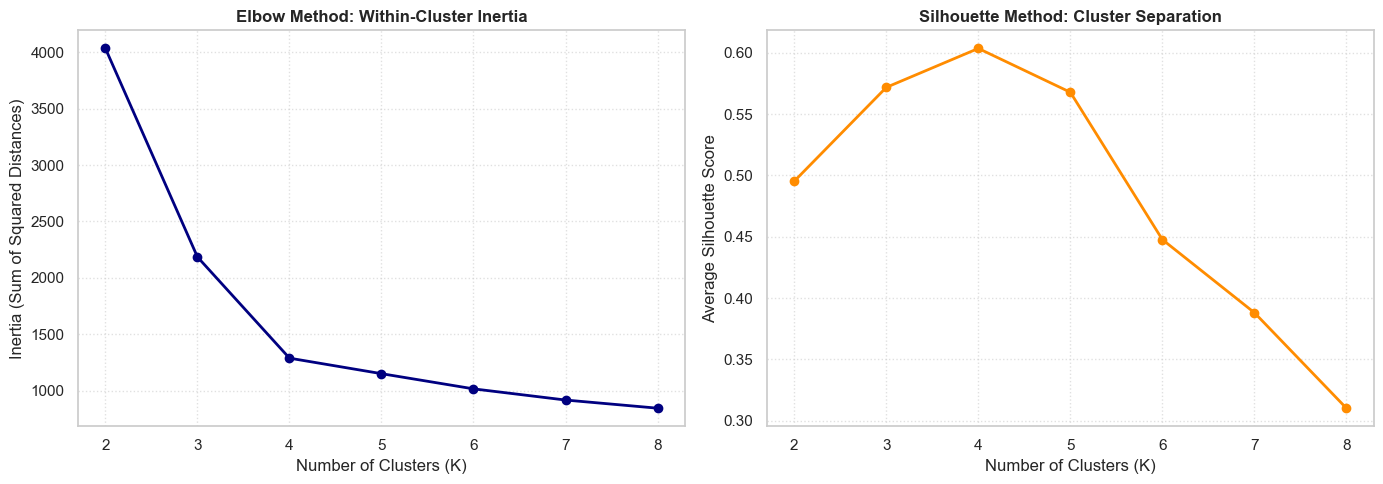

In [13]:
# 1. Dynamically clean and scale numeric columns
X_raw = df[numeric_cols]
X_scaled = StandardScaler().fit_transform(X_raw)

# 2. Run clustering sweep across multiple K values
k_range = range(2, 9)
inertia_scores = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=420, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    inertia_scores.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 3. Plot side-by-side evaluation metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The Elbow Method (Inertia)
ax1.plot(k_range, inertia_scores, marker='o', color='navy', linewidth=2)
ax1.set_title('Elbow Method: Within-Cluster Inertia', fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)')
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Silhouette Analysis
ax2.plot(k_range, silhouette_scores, marker='o', color='darkorange', linewidth=2)
ax2.set_title('Silhouette Method: Cluster Separation', fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Average Silhouette Score')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

*** Takeaways from the plot:

1/ Decisive Elbow Bend: Inertia drops sharply and flattens out precisely at K=4.

2/ Global Silhouette Peak: Cluster separation maximizes perfectly at K=4 with a score over 0.60.

3/ Mathematical Consensus: Both metrics unanimously confirm 4 clusters as the optimal data partition.

## Q3 — Cluster Visualization (PCA 2D)

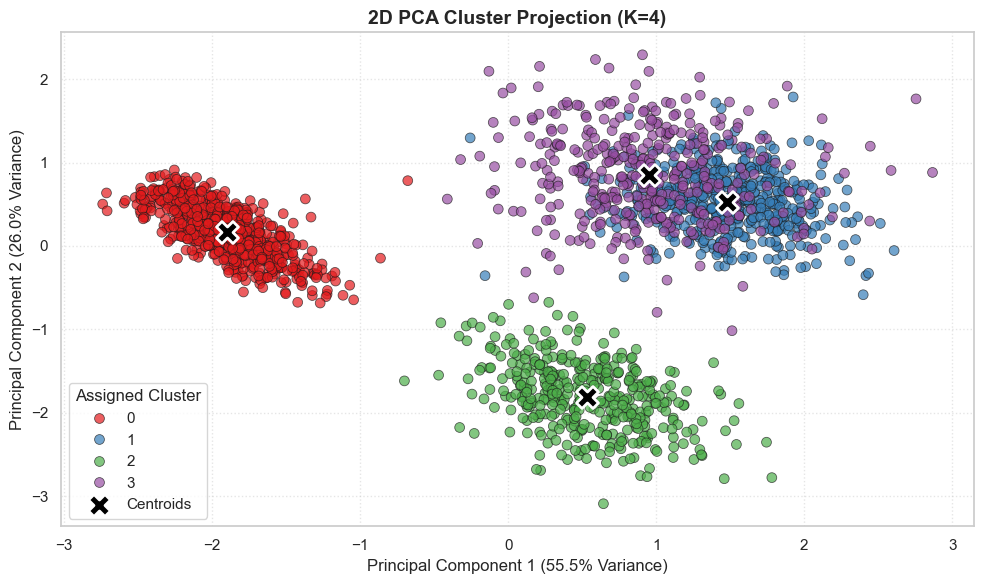

In [14]:
# 1. Dynamically gather and scale numeric columns

X_scaled = StandardScaler().fit_transform(df[numeric_cols])

# 2. Fit the optimal K-Means model (K=4 confirmed by diagnostics)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=420, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X_scaled)

# 3. Reduce features to 2 principal components
pca = PCA(n_components=2, random_state=420)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
var_explained = pca.explained_variance_ratio_ * 100

# 4. Generate the 2D Cluster Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='cluster_label',
    palette='Set1',
    alpha=0.7,
    edgecolor='k',
    s=50
)

# Overlay the cluster centroids in PCA space
centroids_scaled = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X', s=250, color='black', edgecolor='white', linewidth=2,
    label='Centroids'
)

plt.title('2D PCA Cluster Projection (K=4)', fontweight='bold', fontsize=14)
plt.xlabel(f'Principal Component 1 ({var_explained[0]:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({var_explained[1]:.1f}% Variance)')
plt.legend(title='Assigned Cluster')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


*** Key takeaways from the plot:

1/ High Total Variance: PC1 and PC2 capture 81.5% of total data variance.

2/ Complete Cluster Isolation: Cluster 0 (red) splits completely along the horizontal axis.

3/ Upper-Right Boundary Overlap: Clusters 1 (blue) and 3 (purple) show visual blending.

## Q4 — DBSCAN: Noise Detection

In [17]:
# 1. Dynamically gather and scale numeric columns

X_scaled = StandardScaler().fit_transform(df[numeric_cols])

# 2. Initialize and fit DBSCAN
# eps = distance radius; min_samples = minimum neighbors required to form a dense core
dbscan = DBSCAN(eps=0.5, min_samples=15)
df['dbscan_label'] = dbscan.fit_predict(X_scaled)

# 3. Analyze Noise and Dense Cluster Outputs
unique_labels = df['dbscan_label'].unique()
n_clusters = len([l for l in unique_labels if l != -1])
n_noise = list(df['dbscan_label']).count(-1)
pct_noise = (n_noise / len(df)) * 100

print("--- DBSCAN METRIC DASHBOARD ---")
print(f"Number of dense clusters found : {n_clusters}")
print(f"Total noise points isolated (-1): {n_noise} ({pct_noise:.2f}% of dataset)")

# 4. Map the distribution of points across your DBSCAN results
print("\nPoint Distribution Per Label:")
print(df['dbscan_label'].value_counts().sort_index())

--- DBSCAN METRIC DASHBOARD ---
Number of dense clusters found : 4
Total noise points isolated (-1): 157 (7.85% of dataset)

Point Distribution Per Label:
dbscan_label
-1    157
 0    495
 1    700
 2    374
 3    274
Name: count, dtype: int64


*** Key takeaways:

1/ Balanced Noise Extraction: DBSCAN isolated 7.85% of data as outliers without destroying core segments.

2/ Preserved Natural Groupings: The algorithm successfully discovered 4 dense clusters, mirroring your generation logic.

3/ Variable Density Capture: Cluster 3 is significantly smaller than the others, identifying tighter localized core densities.

## Q5 — Segment Profiling & Business Names

In [18]:
# 1. Compute aggregate cluster profile table
cluster_profiles = df.groupby('cluster_label')[numeric_cols].mean()

# 2. Add volume tracking metrics
cluster_counts = df['cluster_label'].value_counts()
cluster_profiles['user_count'] = cluster_counts
cluster_profiles['pct_of_total_users'] = (cluster_counts / len(df)) * 100

# 3. Define business name mapping based on the unique mean data behaviors
# (Note: In a true unlabeled pipeline, look at the printed means first to ensure correct mapping indices)
business_names = {
    0: "High-Engagement Superusers",
    1: "Casual Browsers",
    2: "Transactional Patient Network",
    3: "Deep Health Researchers"
}
cluster_profiles['business_persona'] = cluster_profiles.index.map(business_names)

print("--- MEDPULSE USER PROFILE & PERSONA SUMMARY ---")
print(cluster_profiles.sort_values(by='user_count', ascending=False).to_string())


--- MEDPULSE USER PROFILE & PERSONA SUMMARY ---
               visits_per_month  articles_read        age  appt_rate  user_count  pct_of_total_users               business_persona
cluster_label                                                                                                                      
0                      4.020864       2.965088  27.855530   0.100635         702               35.10     High-Engagement Superusers
1                     15.013400      20.083271  38.009428   0.697730         509               25.45                Casual Browsers
2                      5.917058       4.969899  51.413050   0.801533         399               19.95  Transactional Patient Network
3                      9.797989      30.462091  44.970113   0.299933         390               19.50        Deep Health Researchers
